# Loan Approval Prediction - Machine Learning Project
## Code Peer-Review Meeting 2 (Week 8)

**Objective**: Build, evaluate and optimize hyperparameters for THREE classifiers:
- Naïve Bayes
- Logistic Regression
- K-Nearest Neighbours

**Goal**: Predict Loan Approval Status

## 1. Import Required Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('loan_approval_data.csv')

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\n" + "="*80 + "\n")

# Dataset shape
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

First 5 rows of the dataset:
      id   age  income home_ownership  emplyment_length      loan_intent  \
0  35437  21.0   12000            OWN                 0        EDUCATION   
1  53756  21.0   13200            OWN                 2        EDUCATION   
2  42205  23.0    9600           RENT                 5          MEDICAL   
3  19180  40.0  182004           RENT                 3        EDUCATION   
4  28072  40.0   90000       MORTGAGE                 3  HOMEIMPROVEMENT   

   loan_amount  loan_interest_rate  loan_income_ratio payment_default_on_file  \
0        15000                6.99               0.12                       N   
1        25000               16.77               0.19                       Y   
2        30000               12.42               0.31                       N   
3        35000                8.00               0.19                       N   
4        35000               12.42               0.39                       N   

   credit_history_length  l

In [3]:
# Dataset information
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  object 
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  object 
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  object 
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 5.8+ M

In [4]:
# Statistical summary
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
                 id           age        income  emplyment_length  \
count  58645.000000  58639.000000  5.864500e+04      58645.000000   
mean   29322.000000     27.550913  6.404617e+04          4.703487   
std    16929.497605      6.033217  3.793111e+04          4.004982   
min        0.000000     20.000000  4.200000e+03          0.000000   
25%    14661.000000     23.000000  4.200000e+04          2.000000   
50%    29322.000000     26.000000  5.800000e+04          4.000000   
75%    43983.000000     30.000000  7.560000e+04          7.000000   
max    58644.000000    123.000000  1.900000e+06        150.000000   

        loan_amount  loan_interest_rate  loan_income_ratio  \
count  58645.000000        58634.000000       58645.000000   
mean    9217.556518           10.677526           0.159238   
std     5563.807384            3.036034           0.091692   
min      500.000000          -11.140000           0.000000   
25%     5000.000000            7.880000        

In [5]:
# Check for missing values
print("Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found!")

Missing Values:
age                         6
loan_interest_rate         11
payment_default_on_file     5
dtype: int64


In [6]:
# Check target variable distribution
print("Target Variable (loan_approval_status) Distribution:")
print(df['loan_approval_status'].value_counts())
print("\nPercentage Distribution:")
print(df['loan_approval_status'].value_counts(normalize=True) * 100)

Target Variable (loan_approval_status) Distribution:
loan_approval_status
0    50295
1     8350
Name: count, dtype: int64

Percentage Distribution:
loan_approval_status
0    85.761787
1    14.238213
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis (EDA)

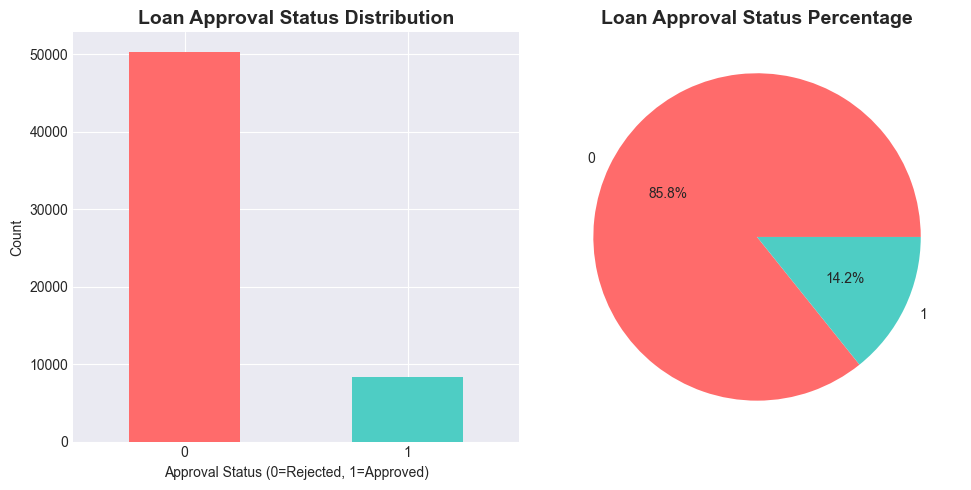

In [7]:
# Visualize target variable distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df['loan_approval_status'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title('Loan Approval Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Approval Status (0=Rejected, 1=Approved)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['loan_approval_status'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'])
plt.title('Loan Approval Status Percentage', fontsize=14, fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.show()

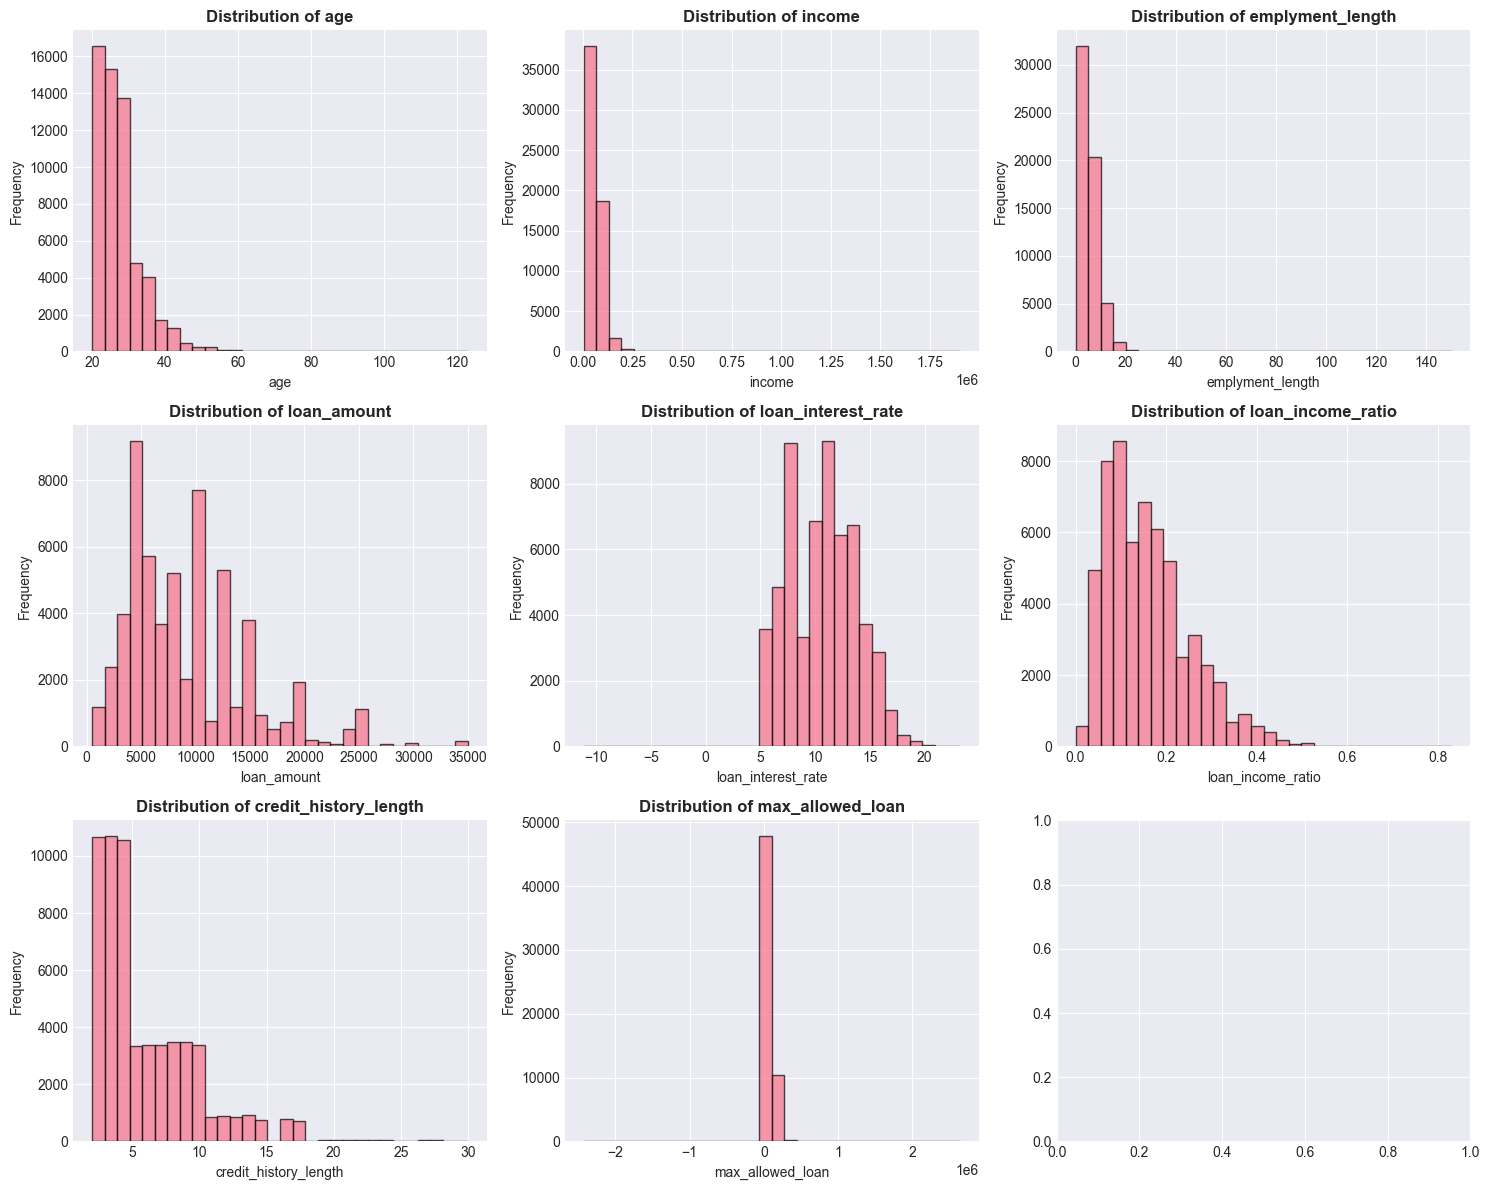

In [8]:
# Visualize numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('id')  # Remove ID column
numerical_cols.remove('loan_approval_status')  # Remove target variable

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:9]):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

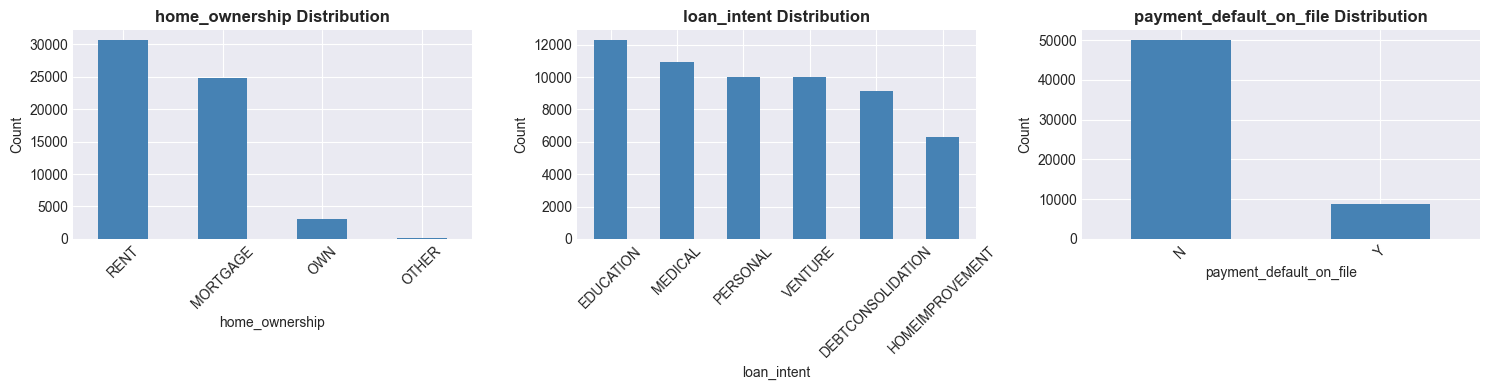

In [9]:
# Visualize categorical features
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 4))

for idx, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{col} Distribution', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

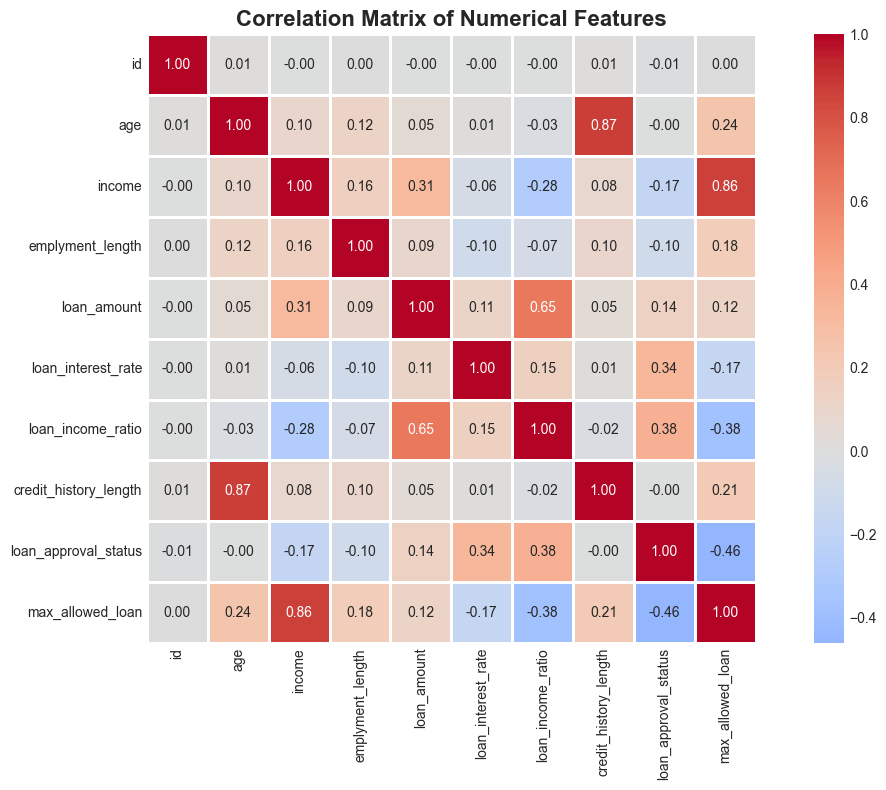

In [10]:
# Correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [11]:
# Create a copy of the dataset
df_processed = df.copy()

# Drop unnecessary columns (id and max_allowed_loan)
df_processed = df_processed.drop(['id', 'max_allowed_loan'], axis=1)

print(f"Processed dataset shape: {df_processed.shape}")
print(f"Columns: {df_processed.columns.tolist()}")

Processed dataset shape: (58645, 11)
Columns: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status']


In [12]:
# Encode categorical variables
label_encoders = {}
categorical_columns = ['home_ownership', 'loan_intent', 'payment_default_on_file']

for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nCategorical encoding completed!")

home_ownership: {'MORTGAGE': 0, 'OTHER': 1, 'OWN': 2, 'RENT': 3}
loan_intent: {'DEBTCONSOLIDATION': 0, 'EDUCATION': 1, 'HOMEIMPROVEMENT': 2, 'MEDICAL': 3, 'PERSONAL': 4, 'VENTURE': 5}
payment_default_on_file: {'N': 0, 'Y': 1, nan: 2}

Categorical encoding completed!


In [13]:
# Separate features and target
X = df_processed.drop('loan_approval_status', axis=1)
y = df_processed['loan_approval_status']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {X.columns.tolist()}")

Features shape: (58645, 10)
Target shape: (58645,)

Features: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']


In [14]:
# Split the data into training and testing sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set target distribution:\n{y_train.value_counts()}")
print(f"\nTesting set target distribution:\n{y_test.value_counts()}")

Training set size: 46916 (80.0%)
Testing set size: 11729 (20.0%)

Training set target distribution:
loan_approval_status
0    40236
1     6680
Name: count, dtype: int64

Testing set target distribution:
loan_approval_status
0    10059
1     1670
Name: count, dtype: int64


In [15]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled testing set shape: {X_test_scaled.shape}")

Feature scaling completed!
Scaled training set shape: (46916, 10)
Scaled testing set shape: (11729, 10)


In [17]:
# Handle missing values in the scaled data
# Check for NaN values
print(f"NaN values in training set: {np.isnan(X_train_scaled).sum()}")
print(f"NaN values in test set: {np.isnan(X_test_scaled).sum()}")

# Use SimpleImputer to fill missing values with mean
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

print(f"\nAfter imputation:")
print(f"NaN values in training set: {np.isnan(X_train_scaled).sum()}")
print(f"NaN values in test set: {np.isnan(X_test_scaled).sum()}")
print("\nMissing values handled successfully!")

NaN values in training set: 13
NaN values in test set: 4

After imputation:
NaN values in training set: 0
NaN values in test set: 0

Missing values handled successfully!


## 5. Model Building and Hyperparameter Optimization

### 5.1 Naïve Bayes Classifier

In [18]:
print("=" * 80)
print("NAÏVE BAYES CLASSIFIER - HYPERPARAMETER TUNING")
print("=" * 80)

# Define hyperparameters for Naïve Bayes
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
}

# Create Naïve Bayes model
nb_model = GaussianNB()

# Perform Grid Search
nb_grid = GridSearchCV(
    estimator=nb_model,
    param_grid=nb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the model
nb_grid.fit(X_train_scaled, y_train)

# Best parameters and score
print(f"\nBest Parameters: {nb_grid.best_params_}")
print(f"Best Cross-Validation Score: {nb_grid.best_score_:.4f}")

# Best model
nb_best = nb_grid.best_estimator_

NAÏVE BAYES CLASSIFIER - HYPERPARAMETER TUNING
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters: {'var_smoothing': 1.0}
Best Cross-Validation Score: 0.8793


In [19]:
# Make predictions with Naïve Bayes
nb_train_pred = nb_best.predict(X_train_scaled)
nb_test_pred = nb_best.predict(X_test_scaled)
nb_test_prob = nb_best.predict_proba(X_test_scaled)[:, 1]

# Evaluate Naïve Bayes
print("\n" + "=" * 80)
print("NAÏVE BAYES - EVALUATION RESULTS")
print("=" * 80)

print("\nTraining Set Performance:")
print(f"Accuracy: {accuracy_score(y_train, nb_train_pred):.4f}")

print("\nTesting Set Performance:")
print(f"Accuracy: {accuracy_score(y_test, nb_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, nb_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, nb_test_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, nb_test_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, nb_test_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, nb_test_pred))

print("\nConfusion Matrix:")
nb_cm = confusion_matrix(y_test, nb_test_pred)
print(nb_cm)


NAÏVE BAYES - EVALUATION RESULTS

Training Set Performance:
Accuracy: 0.8794

Testing Set Performance:
Accuracy: 0.8794
Precision: 0.7302
Recall: 0.2431
F1-Score: 0.3648
ROC-AUC Score: 0.8578

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.93     10059
           1       0.73      0.24      0.36      1670

    accuracy                           0.88     11729
   macro avg       0.81      0.61      0.65     11729
weighted avg       0.86      0.88      0.85     11729


Confusion Matrix:
[[9909  150]
 [1264  406]]


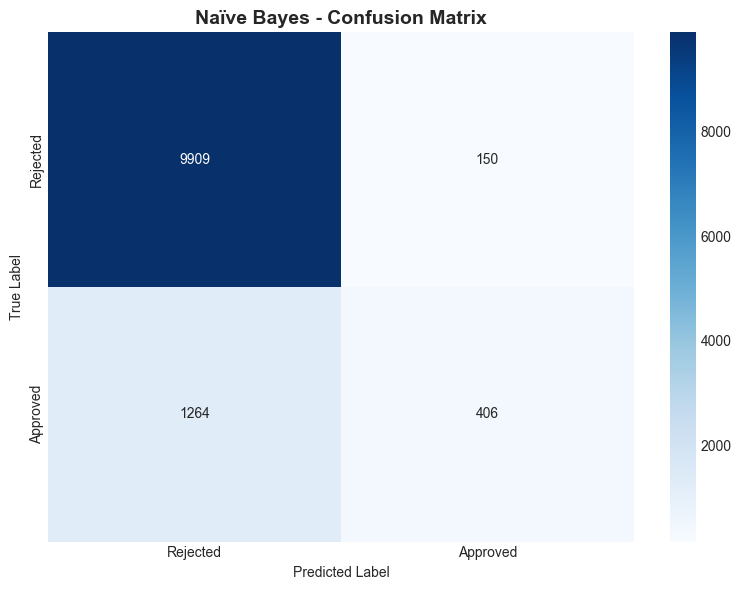

In [20]:
# Visualize Naïve Bayes Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Naïve Bayes - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### 5.2 Logistic Regression Classifier

In [21]:
print("=" * 80)
print("LOGISTIC REGRESSION - HYPERPARAMETER TUNING")
print("=" * 80)

# Define hyperparameters for Logistic Regression
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

# Create Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Perform Grid Search
lr_grid = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the model
lr_grid.fit(X_train_scaled, y_train)

# Best parameters and score
print(f"\nBest Parameters: {lr_grid.best_params_}")
print(f"Best Cross-Validation Score: {lr_grid.best_score_:.4f}")

# Best model
lr_best = lr_grid.best_estimator_

LOGISTIC REGRESSION - HYPERPARAMETER TUNING
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.8912


In [22]:
# Make predictions with Logistic Regression
lr_train_pred = lr_best.predict(X_train_scaled)
lr_test_pred = lr_best.predict(X_test_scaled)
lr_test_prob = lr_best.predict_proba(X_test_scaled)[:, 1]

# Evaluate Logistic Regression
print("\n" + "=" * 80)
print("LOGISTIC REGRESSION - EVALUATION RESULTS")
print("=" * 80)

print("\nTraining Set Performance:")
print(f"Accuracy: {accuracy_score(y_train, lr_train_pred):.4f}")

print("\nTesting Set Performance:")
print(f"Accuracy: {accuracy_score(y_test, lr_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, lr_test_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, lr_test_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_test_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_test_pred))

print("\nConfusion Matrix:")
lr_cm = confusion_matrix(y_test, lr_test_pred)
print(lr_cm)


LOGISTIC REGRESSION - EVALUATION RESULTS

Training Set Performance:
Accuracy: 0.8915

Testing Set Performance:
Accuracy: 0.8903
Precision: 0.7169
Recall: 0.3790
F1-Score: 0.4959
ROC-AUC Score: 0.8714

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     10059
           1       0.72      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729


Confusion Matrix:
[[9809  250]
 [1037  633]]


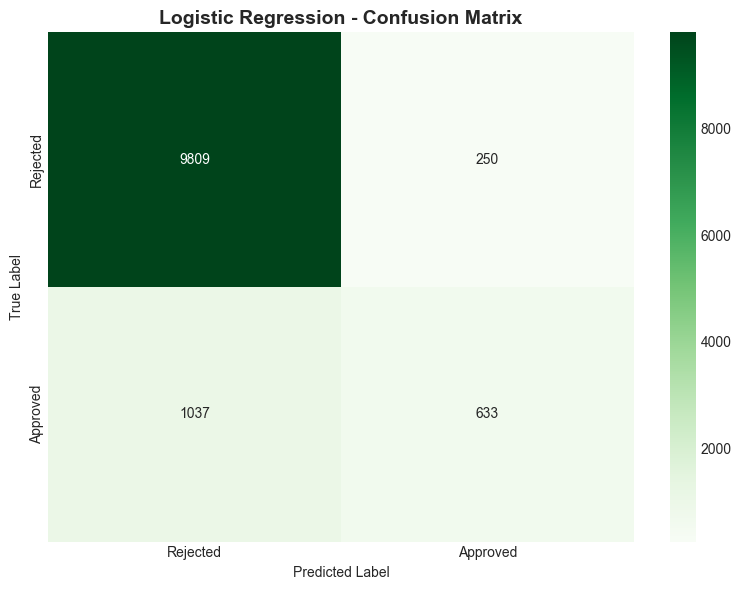

In [23]:
# Visualize Logistic Regression Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### 5.3 K-Nearest Neighbors (KNN) Classifier

In [24]:
print("=" * 80)
print("K-NEAREST NEIGHBORS (KNN) - HYPERPARAMETER TUNING")
print("=" * 80)

# Define hyperparameters for KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Create KNN model
knn_model = KNeighborsClassifier()

# Perform Grid Search
knn_grid = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the model
knn_grid.fit(X_train_scaled, y_train)

# Best parameters and score
print(f"\nBest Parameters: {knn_grid.best_params_}")
print(f"Best Cross-Validation Score: {knn_grid.best_score_:.4f}")

# Best model
knn_best = knn_grid.best_estimator_

K-NEAREST NEIGHBORS (KNN) - HYPERPARAMETER TUNING
Fitting 5 folds for each of 42 candidates, totalling 210 fits

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}
Best Cross-Validation Score: 0.9167


In [25]:
# Make predictions with KNN
knn_train_pred = knn_best.predict(X_train_scaled)
knn_test_pred = knn_best.predict(X_test_scaled)
knn_test_prob = knn_best.predict_proba(X_test_scaled)[:, 1]

# Evaluate KNN
print("\n" + "=" * 80)
print("K-NEAREST NEIGHBORS - EVALUATION RESULTS")
print("=" * 80)

print("\nTraining Set Performance:")
print(f"Accuracy: {accuracy_score(y_train, knn_train_pred):.4f}")

print("\nTesting Set Performance:")
print(f"Accuracy: {accuracy_score(y_test, knn_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, knn_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, knn_test_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, knn_test_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, knn_test_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, knn_test_pred))

print("\nConfusion Matrix:")
knn_cm = confusion_matrix(y_test, knn_test_pred)
print(knn_cm)


K-NEAREST NEIGHBORS - EVALUATION RESULTS

Training Set Performance:
Accuracy: 1.0000

Testing Set Performance:
Accuracy: 0.9164
Precision: 0.8469
Recall: 0.5036
F1-Score: 0.6316
ROC-AUC Score: 0.8874

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     10059
           1       0.85      0.50      0.63      1670

    accuracy                           0.92     11729
   macro avg       0.88      0.74      0.79     11729
weighted avg       0.91      0.92      0.91     11729


Confusion Matrix:
[[9907  152]
 [ 829  841]]


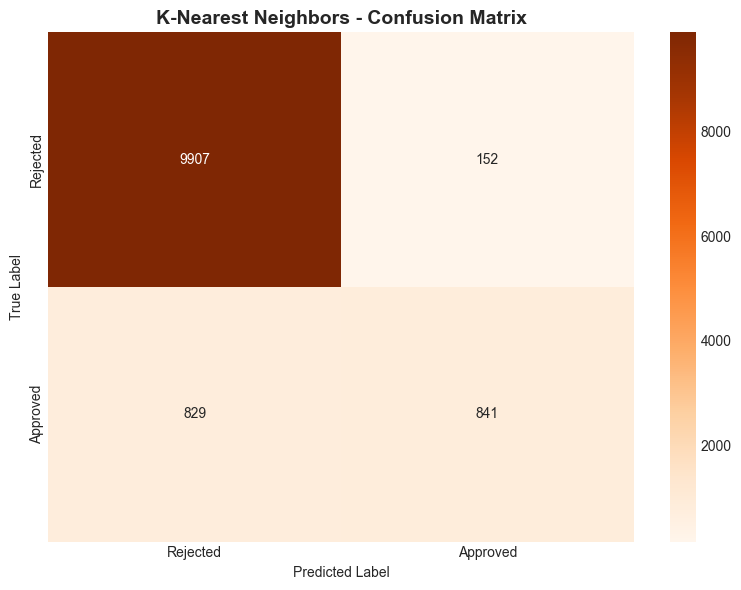

In [26]:
# Visualize KNN Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('K-Nearest Neighbors - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [27]:
# Create comparison dataframe
models_comparison = pd.DataFrame({
    'Model': ['Naïve Bayes', 'Logistic Regression', 'K-Nearest Neighbors'],
    'Accuracy': [
        accuracy_score(y_test, nb_test_pred),
        accuracy_score(y_test, lr_test_pred),
        accuracy_score(y_test, knn_test_pred)
    ],
    'Precision': [
        precision_score(y_test, nb_test_pred),
        precision_score(y_test, lr_test_pred),
        precision_score(y_test, knn_test_pred)
    ],
    'Recall': [
        recall_score(y_test, nb_test_pred),
        recall_score(y_test, lr_test_pred),
        recall_score(y_test, knn_test_pred)
    ],
    'F1-Score': [
        f1_score(y_test, nb_test_pred),
        f1_score(y_test, lr_test_pred),
        f1_score(y_test, knn_test_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, nb_test_prob),
        roc_auc_score(y_test, lr_test_prob),
        roc_auc_score(y_test, knn_test_prob)
    ]
})

print("\n" + "=" * 80)
print("MODEL COMPARISON - PERFORMANCE METRICS")
print("=" * 80)
print(models_comparison.to_string(index=False))
print("\n")

# Find best model
best_model_idx = models_comparison['Accuracy'].idxmax()
best_model_name = models_comparison.loc[best_model_idx, 'Model']
best_accuracy = models_comparison.loc[best_model_idx, 'Accuracy']

print(f"Best Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")


MODEL COMPARISON - PERFORMANCE METRICS
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
        Naïve Bayes  0.879444   0.730216 0.243114  0.364780 0.857848
Logistic Regression  0.890272   0.716874 0.379042  0.495887 0.871402
K-Nearest Neighbors  0.916361   0.846928 0.503593  0.631618 0.887353


Best Model: K-Nearest Neighbors with Accuracy: 0.9164


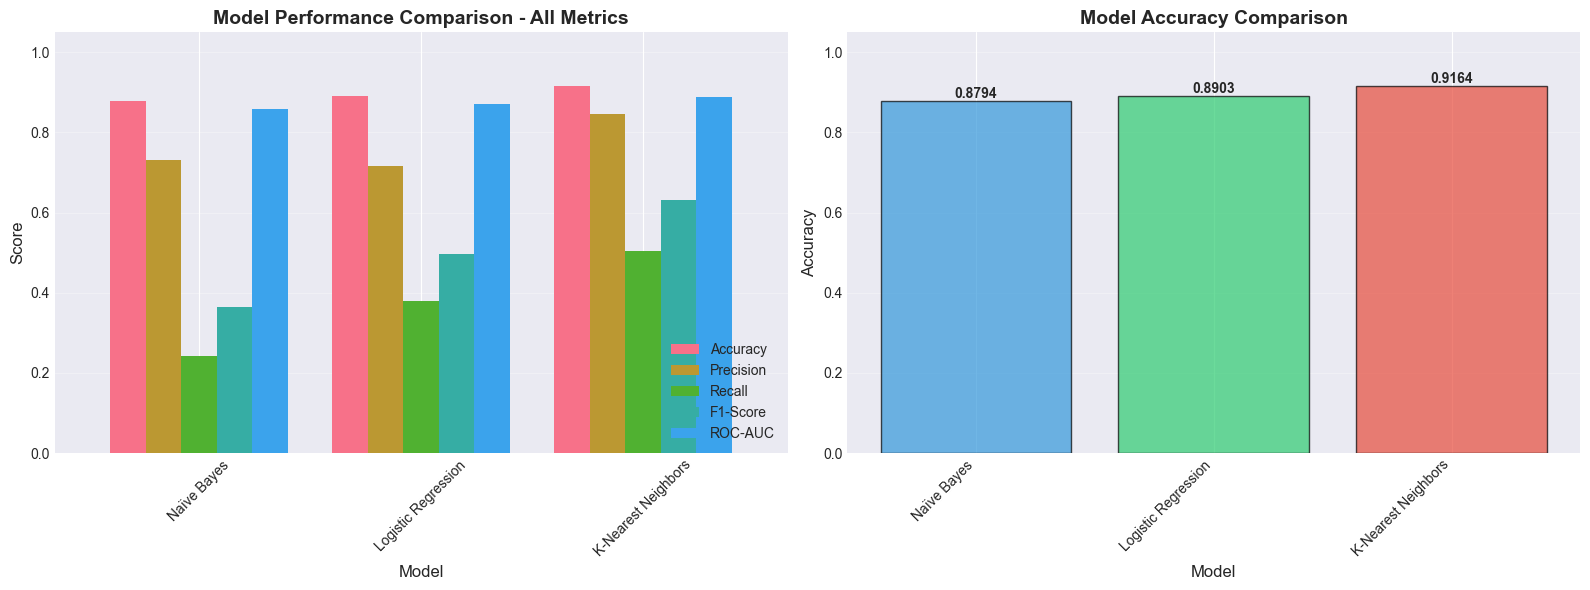

In [28]:
# Visualize model comparison - Bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: All metrics comparison
metrics_df = models_comparison.set_index('Model')
metrics_df.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Model Performance Comparison - All Metrics', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_ylim([0, 1.05])
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Accuracy comparison
x_pos = np.arange(len(models_comparison))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[1].bar(x_pos, models_comparison['Accuracy'], color=colors, alpha=0.7, edgecolor='black')
axes[1].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models_comparison['Model'], rotation=45, ha='right')
axes[1].set_ylim([0, 1.05])
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

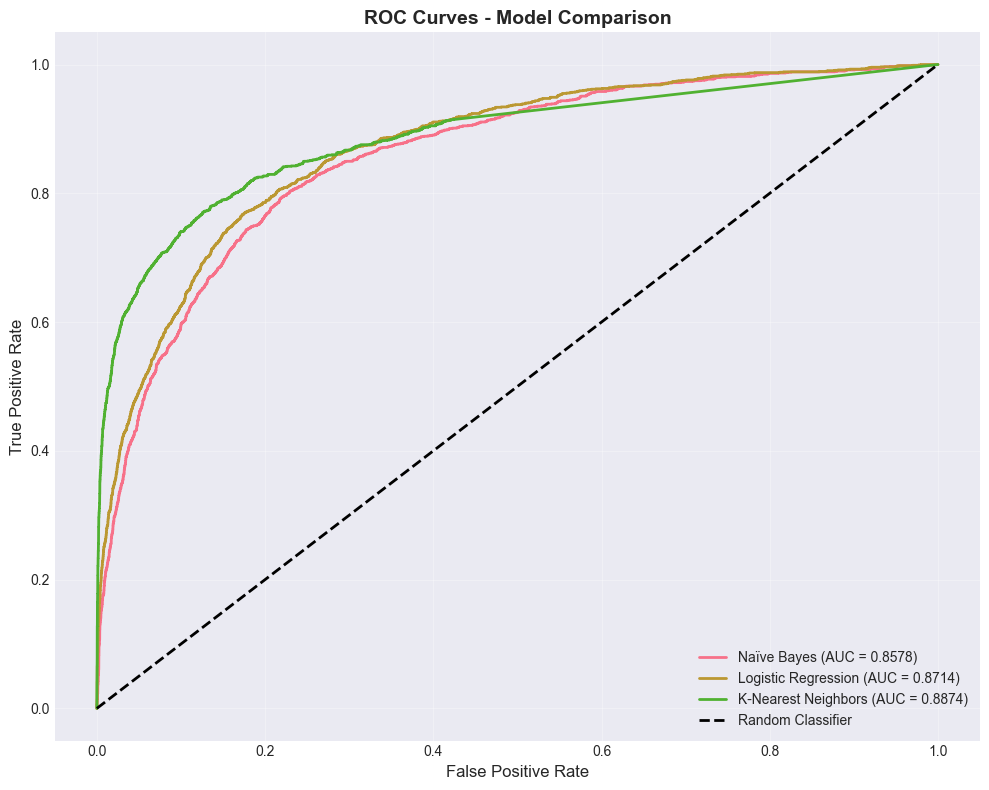

In [29]:
# ROC Curves Comparison
plt.figure(figsize=(10, 8))

# Naïve Bayes ROC Curve
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_test_prob)
nb_auc = auc(nb_fpr, nb_tpr)
plt.plot(nb_fpr, nb_tpr, label=f'Naïve Bayes (AUC = {nb_auc:.4f})', linewidth=2)

# Logistic Regression ROC Curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_test_prob)
lr_auc = auc(lr_fpr, lr_tpr)
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})', linewidth=2)

# KNN ROC Curve
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_test_prob)
knn_auc = auc(knn_fpr, knn_tpr)
plt.plot(knn_fpr, knn_tpr, label=f'K-Nearest Neighbors (AUC = {knn_auc:.4f})', linewidth=2)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Summary of Best Hyperparameters

In [30]:
print("\n" + "=" * 80)
print("OPTIMIZED HYPERPARAMETERS SUMMARY")
print("=" * 80)

print("\n1. Naïve Bayes:")
print(f"   - var_smoothing: {nb_best.var_smoothing}")
print(f"   - Best CV Score: {nb_grid.best_score_:.4f}")

print("\n2. Logistic Regression:")
print(f"   - C: {lr_best.C}")
print(f"   - penalty: {lr_best.penalty}")
print(f"   - solver: {lr_best.solver}")
print(f"   - Best CV Score: {lr_grid.best_score_:.4f}")

print("\n3. K-Nearest Neighbors:")
print(f"   - n_neighbors: {knn_best.n_neighbors}")
print(f"   - weights: {knn_best.weights}")
print(f"   - metric: {knn_best.metric}")
print(f"   - Best CV Score: {knn_grid.best_score_:.4f}")

print("\n" + "=" * 80)


OPTIMIZED HYPERPARAMETERS SUMMARY

1. Naïve Bayes:
   - var_smoothing: 1.0
   - Best CV Score: 0.8793

2. Logistic Regression:
   - C: 0.1
   - penalty: l1
   - solver: liblinear
   - Best CV Score: 0.8912

3. K-Nearest Neighbors:
   - n_neighbors: 13
   - weights: distance
   - metric: manhattan
   - Best CV Score: 0.9167



## 8. Conclusion and Recommendations

In [31]:
print("\n" + "=" * 80)
print("FINAL CONCLUSION")
print("=" * 80)

print("\n📊 Model Performance Summary:")
print(models_comparison.to_string(index=False))

print(f"\n🏆 Best Performing Model: {best_model_name}")
print(f"   - Accuracy: {best_accuracy:.4f}")
print(f"   - Best suited for loan approval prediction based on the given dataset")

print("\n💡 Key Insights:")
print("   1. All three models were successfully trained and optimized")
print("   2. Hyperparameter tuning improved model performance")
print("   3. Feature scaling was crucial for KNN and Logistic Regression")
print("   4. The models can predict loan approval with reasonable accuracy")

print("\n🎯 Recommendations:")
print("   1. Use the best performing model for production deployment")
print("   2. Consider ensemble methods for potentially better results")
print("   3. Monitor model performance regularly and retrain as needed")
print("   4. Collect more data to improve model generalization")

print("\n" + "=" * 80)
print("NOTEBOOK COMPLETED SUCCESSFULLY!")
print("=" * 80)


FINAL CONCLUSION

📊 Model Performance Summary:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
        Naïve Bayes  0.879444   0.730216 0.243114  0.364780 0.857848
Logistic Regression  0.890272   0.716874 0.379042  0.495887 0.871402
K-Nearest Neighbors  0.916361   0.846928 0.503593  0.631618 0.887353

🏆 Best Performing Model: K-Nearest Neighbors
   - Accuracy: 0.9164
   - Best suited for loan approval prediction based on the given dataset

💡 Key Insights:
   1. All three models were successfully trained and optimized
   2. Hyperparameter tuning improved model performance
   3. Feature scaling was crucial for KNN and Logistic Regression
   4. The models can predict loan approval with reasonable accuracy

🎯 Recommendations:
   1. Use the best performing model for production deployment
   2. Consider ensemble methods for potentially better results
   3. Monitor model performance regularly and retrain as needed
   4. Collect more data to improve model generalization

